In [11]:
import numpy as np
import matplotlib.pyplot as plt

import h5ify

import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp

from models import BrokenPowerlawPlusTwoPeaks_PrimaryMass_FullSmooth

In [7]:
det = h5ify.load('../data/vt/test/detectable.hdf5')

In [8]:
injs = h5ify.load('../data/vt/test/all.hdf5')

In [9]:
import json
with open('./parameters/vt-o4a-strong-maxl-iso-tilts.json', 'r') as f:
    parameters = json.loads(f.read())

In [26]:
test_m1s = jnp.linspace(3, 300, 2_000)
p_m1 = np.exp(BrokenPowerlawPlusTwoPeaks_PrimaryMass_FullSmooth(
    dict(mass_1=test_m1s),
    alpha_1=parameters['alpha_1'],
    alpha_2=parameters['alpha_2'],
    mlow_1=parameters['mlow_1'],
    break_mass=parameters['break_mass'],
    delta_m_1=parameters['delta_m_1'],
    lam_fractions=(
        parameters['lam_0'], parameters['lam_1'], parameters['lam_2']
    ),
    mpp_1=parameters['mpp_1'],
    sigpp_1=parameters['sigpp_1'],
    mpp_2=parameters['mpp_2'],
    sigpp_2=parameters['sigpp_2'],
    mmax=300.0,
    gaussian_mass_maximum=100.0
))

Text(0, 0.5, '$p(m_1)$')

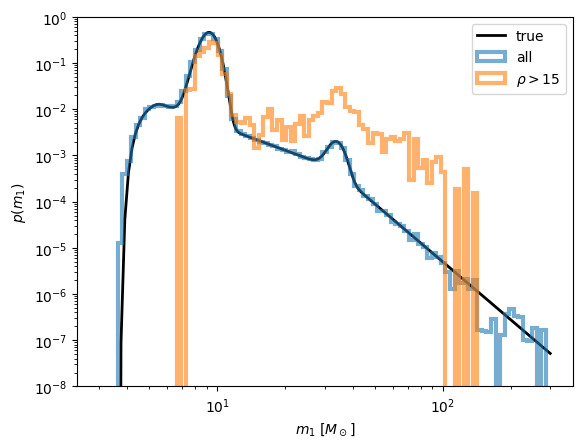

In [29]:
fig, ax = plt.subplots()
ax.plot(
    test_m1s,
    p_m1,
    color='black',
    linewidth=2,
    label='true'
)
ax.hist(
    injs['mass_1_source'],
    histtype='step',
    bins=np.logspace(np.log10(3), np.log10(300), 100),
    density=True,
    linewidth=3,
    alpha=0.6,
    label='all'
)
ax.hist(
    det['mass_1_source'],
    histtype='step',
    bins=np.logspace(np.log10(3), np.log10(300), 100),
    density=True,
    linewidth=3,
    alpha=0.6,
    label=r'$\rho > 15$'
)
ax.loglog()
ax.set_ylim(1e-8, 1e0)
ax.legend()

ax.set_xlabel(r'$m_1$ [$M_\odot$]')
ax.set_ylabel(r'$p(m_1)$')

In [30]:
from pixelpop.models.gwpop_models import PowerlawPlusPeak_MassRatio

m1s = jnp.linspace(3, 300, 500)
qs = jnp.linspace(0.1, 1, 500)
mm, qq = jnp.meshgrid(m1s, qs, indexing='ij')

p_m1 = jnp.exp(BrokenPowerlawPlusTwoPeaks_PrimaryMass_FullSmooth(
    dict(mass_1=mm),
    alpha_1=parameters['alpha_1'],
    alpha_2=parameters['alpha_2'],
    mlow_1=parameters['mlow_1'],
    break_mass=parameters['break_mass'],
    delta_m_1=parameters['delta_m_1'],
    lam_fractions=(
        parameters['lam_0'], parameters['lam_1'], parameters['lam_2']
    ),
    mpp_1=parameters['mpp_1'],
    sigpp_1=parameters['sigpp_1'],
    mpp_2=parameters['mpp_2'],
    sigpp_2=parameters['sigpp_2'],
    mmax=300.0,
    gaussian_mass_maximum=100.0
))

log_p_q_given_m1 = PowerlawPlusPeak_MassRatio(
    dict(mass_1=mm, mass_ratio=qq),
    slope=parameters['beta'],
    minimum=parameters['mlow_1'],
    delta_m=parameters['delta_m_1']
)
p_q_given_m1 = jnp.exp(log_p_q_given_m1)

p_m1q = p_m1 * p_q_given_m1
p_q = jnp.trapezoid(p_m1q, m1s, axis=0)

Text(0, 0.5, '$p(q)$')

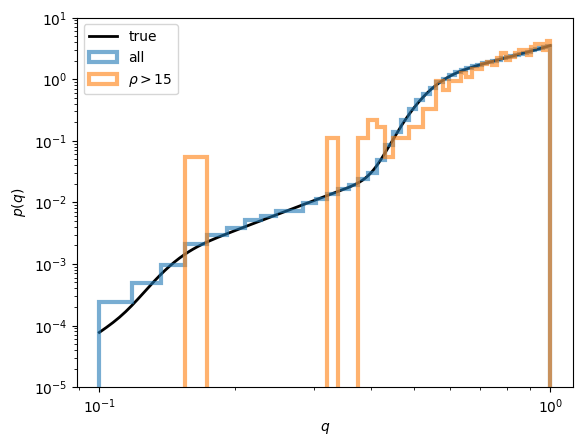

In [33]:
fig, ax = plt.subplots()
ax.plot(
    qs,
    p_q,
    color='black',
    linewidth=2,
    label='true'
)
ax.hist(
    injs['mass_ratio'],
    histtype='step',
    bins=np.linspace(0.1, 1, 50),
    density=True,
    linewidth=3,
    alpha=0.6,
    label='all'
)
ax.hist(
    det['mass_ratio'],
    histtype='step',
    bins=np.linspace(0.1, 1, 50),
    density=True,
    linewidth=3,
    alpha=0.6,
    label=r'$\rho > 15$'
)
ax.loglog()
ax.set_ylim(1e-5, 1e1)
ax.legend()

ax.set_xlabel(r'$q$')
ax.set_ylabel(r'$p(q)$')

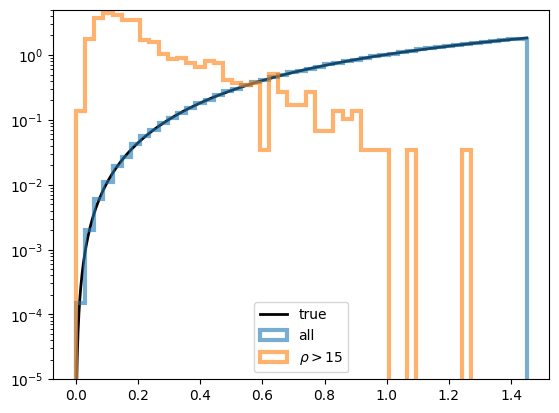

In [52]:
from models import log_powerlaw_redshift

z_max = parameters['z_max']
zs = np.linspace(1e-5, z_max, 1000)
pz = np.exp(log_powerlaw_redshift(
    dict(redshift=zs),
    parameters
))

fig, ax = plt.subplots()
ax.plot(
    zs,
    pz,
    color='black',
    linewidth=2,
    label='true'
)

ax.hist(
    injs['redshift'],
    histtype='step',
    bins=np.linspace(0, 1.45, 50),
    density=True,
    linewidth=3,
    alpha=0.6,
    label='all'
)
ax.hist(
    det['redshift'],
    histtype='step',
    bins=np.linspace(0, 1.45, 50),
    density=True,
    linewidth=3,
    alpha=0.6,
    label=r'$\rho > 15$'
)

ax.set_yscale('log')
ax.set_ylim(1e-5, 5e0)
ax.legend();